# 📊 EDA Dataset OCR — Informasi Gizi Kemasan Makanan
> **Tujuan:** Menganalisis kualitas dataset gambar crop dan file CSV label untuk pelatihan model CRNN deteksi teks informasi gizi.

**Cakupan Analisis:**
1. Kualitas CSV (missing, duplikat, distribusi teks)
2. Kualitas Gambar (resolusi, rasio aspek, brightness, blur)
3. Konsistensi CSV ↔ Gambar
4. Class balance per kategori nutrisi
5. Ringkasan rekomendasi untuk AI Engineer

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install dependencies
!pip install opencv-python pandas matplotlib seaborn openpyxl tqdm -q

Mounted at /content/drive


## 0. Setup & Konfigurasi

In [2]:
# Install jika belum ada
# !pip install opencv-python pandas matplotlib seaborn openpyxl tqdm -q

import os, re, warnings
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm.notebook import tqdm
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams.update({'figure.dpi': 150, 'font.family': 'DejaVu Sans'})

# ── KONFIGURASI PATH (Diperbaiki: menggunakan huruf kecil) ────────
IMG_DIR    = '/content/drive/MyDrive/ocr_crop_v3/cleaned/test'
VALID_DIR  = '/content/drive/MyDrive/ocr_crop_v3/cleaned/valid'
OUTPUT_DIR = '/content/drive/MyDrive/ocr_crop_v3/cleaned/eda_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

IMG_EXTS   = {'.png', '.jpg', '.jpeg', '.bmp', '.webp'}
NUTRISI_CLASSES = ['calories', 'fat', 'carbs', 'sugar', 'sodium']  # sesuaikan jika berbeda

print('✅ Setup selesai')
print(f'   IMG_DIR   : {IMG_DIR}')
print(f'   VALID_DIR : {VALID_DIR}')
print(f'   OUTPUT_DIR: {OUTPUT_DIR}')

✅ Setup selesai
   IMG_DIR   : /content/drive/MyDrive/ocr_crop_v3/cleaned/test
   VALID_DIR : /content/drive/MyDrive/ocr_crop_v3/cleaned/valid
   OUTPUT_DIR: /content/drive/MyDrive/ocr_crop_v3/cleaned/eda_output


## 1. Load Data

In [3]:
# ── Load Excel → DataFrame CSV ────────────────────────────────
# Debug: List contents of VALID_DIR
print(f'Mengecek isi VALID_DIR: {VALID_DIR}')
try:
    valid_dir_contents = list(Path(VALID_DIR).iterdir())
    if not valid_dir_contents:
        print('❌ VALID_DIR kosong atau tidak dapat diakses.')
    else:
        print(f'   Ditemukan: {[f.name for f in valid_dir_contents]}')

    excel_files = list(Path(VALID_DIR).glob('*.xlsx')) + list(Path(VALID_DIR).glob('*.xls'))
    csv_files   = list(Path(VALID_DIR).glob('*.csv'))

    if excel_files:
        df_label = pd.read_excel(excel_files[0])
        print(f'📄 Excel dimuat: {excel_files[0].name} ({len(df_label)} baris)')
    elif csv_files:
        df_label = pd.read_csv(csv_files[0])
        print(f'📄 CSV dimuat: {csv_files[0].name} ({len(df_label)} baris)')
    else:
        raise FileNotFoundError('❌ Tidak ada file Excel/CSV di VALID_DIR')

    # Normalisasi nama kolom
    df_label.columns = df_label.columns.str.strip().str.lower()
    print(f'   Kolom: {list(df_label.columns)}')
    display(df_label.head())
except Exception as e:
    print(f'An error occurred: {e}')

Mengecek isi VALID_DIR: /content/drive/MyDrive/ocr_crop_v3/cleaned/valid
   Ditemukan: ['valid.csv']
📄 CSV dimuat: valid.csv (2391 baris)
   Kolom: ['file_name', 'text']


,file_name,text
0,calories_0002.png,Energi Total 151 kkal 69 kcal
1,calories_0010.png,Energi Total 70 kkal
2,calories_0040.png,Energi Total 100 kkal
3,calories_0041.png,Energi Total 90 kkal
4,calories_0043.png,Energi Total 80 kkal


In [4]:
# ── Scan semua gambar ─────────────────────────────────────────
img_files = [
    f for f in os.listdir(IMG_DIR)
    if Path(f).suffix.lower() in IMG_EXTS
]
print(f'🖼️  Total gambar ditemukan: {len(img_files)}')
print(f'📋 Total baris CSV label : {len(df_label)}')

🖼️  Total gambar ditemukan: 2391
📋 Total baris CSV label : 2391


## 2. Analisis Kualitas CSV

In [5]:
print('='*55)
print('  ANALISIS KUALITAS CSV LABEL')
print('='*55)

total    = len(df_label)
missing  = df_label['text'].isna().sum()
empty    = (df_label['text'].astype(str).str.strip() == '').sum()
dup_rows = df_label.duplicated(subset=['file_name']).sum()
dup_text = df_label.duplicated(subset=['text']).sum()
short    = (df_label['text'].astype(str).str.len() < 3).sum()

print(f'  Total baris          : {total}')
print(f'  Missing (NaN)        : {missing}  ({missing/total*100:.1f}%)')
print(f'  Teks kosong          : {empty}  ({empty/total*100:.1f}%)')
print(f'  Duplikat file_name   : {dup_rows}')
print(f'  Duplikat teks        : {dup_text}')
print(f'  Teks sangat pendek   : {short}  (< 3 karakter)')

# Panjang teks
df_label['text_len'] = df_label['text'].astype(str).str.len()
print(f'\n  Panjang teks (karakter):')
print(f'  Min    : {df_label["text_len"].min()}')
print(f'  Max    : {df_label["text_len"].max()}')
print(f'  Median : {df_label["text_len"].median():.0f}')
print(f'  Mean   : {df_label["text_len"].mean():.1f}')

  ANALISIS KUALITAS CSV LABEL
  Total baris          : 2391
  Missing (NaN)        : 0  (0.0%)
  Teks kosong          : 0  (0.0%)
  Duplikat file_name   : 0
  Duplikat teks        : 1681
  Teks sangat pendek   : 0  (< 3 karakter)

  Panjang teks (karakter):
  Min    : 7
  Max    : 50
  Median : 22
  Mean   : 25.5


In [6]:
# Ekstrak kelas dari file_name (prefix sebelum '_')
df_label['class'] = df_label['file_name'].astype(str).apply(
    lambda x: x.split('_')[0].lower()
)

print('Distribusi kelas dalam CSV:')
print(df_label['class'].value_counts().to_string())

Distribusi kelas dalam CSV:
class
sodium      491
carbs       484
calories    480
fat         479
sugar       457


## 3. Analisis Kualitas Gambar

In [7]:
print('Mengekstrak fitur gambar... (mungkin 2-5 menit)\n')

def laplacian_variance(gray_img):
    """Mengukur ketajaman gambar. Nilai rendah = blur."""
    return cv2.Laplacian(gray_img, cv2.CV_64F).var()

def mean_brightness(gray_img):
    return gray_img.mean()

records = []
corrupt = []

for fname in tqdm(img_files, desc='Scan Gambar'):
    fpath = os.path.join(IMG_DIR, fname)
    img   = cv2.imread(fpath)

    if img is None:
        corrupt.append(fname)
        continue

    h, w  = img.shape[:2]
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    class_name = fname.split('_')[0].lower()

    records.append({
        'file_name'  : fname,
        'class'      : class_name,
        'width'      : w,
        'height'     : h,
        'aspect_ratio': round(w / h, 3),
        'megapixels' : round((w * h) / 1e6, 4),
        'blur_score' : round(laplacian_variance(gray), 2),
        'brightness' : round(mean_brightness(gray), 2),
    })

df_img = pd.DataFrame(records)

print(f'\n✅ Selesai. Total valid: {len(df_img)} | Corrupt/gagal baca: {len(corrupt)}')
if corrupt:
    print(f'   File corrupt: {corrupt[:5]}...')
df_img.describe().round(2)

Mengekstrak fitur gambar... (mungkin 2-5 menit)



Scan Gambar:   0%|          | 0/2391 [00:00<?, ?it/s]


✅ Selesai. Total valid: 2391 | Corrupt/gagal baca: 0


,width,height,aspect_ratio,megapixels,blur_score,brightness
count,2391.00,2391.0,2391.00,2391.00,2391.00,2391.00
mean,595.90,64.0,9.31,0.04,539.48,155.42
std,197.94,0.0,3.09,0.01,564.55,36.57
min,189.00,64.0,2.95,0.01,29.45,31.32
25%,449.50,64.0,7.02,0.03,229.30,135.01
50%,568.00,64.0,8.88,0.04,370.53,158.78
75%,721.00,64.0,11.27,0.05,623.60,181.48
max,1456.00,64.0,22.75,0.09,5751.16,224.75


## 4. Konsistensi CSV ↔ Gambar

In [8]:
csv_files_set = set(df_label['file_name'].astype(str))
img_files_set = set(img_files)

in_csv_not_img = csv_files_set - img_files_set
in_img_not_csv = img_files_set - csv_files_set
matched        = csv_files_set & img_files_set

print('='*55)
print('  KONSISTENSI CSV ↔ FOLDER GAMBAR')
print('='*55)
print(f'  Matched (ada di keduanya)    : {len(matched)}')
print(f'  Ada di CSV, TIDAK di folder  : {len(in_csv_not_img)}')
print(f'  Ada di folder, TIDAK di CSV  : {len(in_img_not_csv)}')

match_rate = len(matched) / max(len(csv_files_set), len(img_files_set)) * 100
print(f'\n  ✅ Match rate: {match_rate:.1f}%')

if in_csv_not_img:
    print(f'\n  Contoh file di CSV tapi tidak ada gambar:')
    for f in list(in_csv_not_img)[:5]: print(f'    - {f}')

if in_img_not_csv:
    print(f'\n  Contoh gambar tidak ada di CSV:')
    for f in list(in_img_not_csv)[:5]: print(f'    - {f}')

  KONSISTENSI CSV ↔ FOLDER GAMBAR
  Matched (ada di keduanya)    : 2391
  Ada di CSV, TIDAK di folder  : 0
  Ada di folder, TIDAK di CSV  : 0

  ✅ Match rate: 100.0%


## 5. Deteksi Anomali Gambar

In [9]:
# Threshold anomali — sesuaikan jika perlu
BLUR_THRESHOLD       = 50    # di bawah ini = blur/buram
BRIGHTNESS_LOW       = 30    # terlalu gelap
BRIGHTNESS_HIGH      = 225   # terlalu terang/overexposed
ASPECT_RATIO_MAX     = 15.0  # terlalu panjang/sempit
MIN_WIDTH            = 30    # terlalu kecil
MIN_HEIGHT           = 10

df_img['is_blur']      = df_img['blur_score'] < BLUR_THRESHOLD
df_img['is_dark']      = df_img['brightness'] < BRIGHTNESS_LOW
df_img['is_bright']    = df_img['brightness'] > BRIGHTNESS_HIGH
df_img['is_odd_ratio'] = df_img['aspect_ratio'] > ASPECT_RATIO_MAX
df_img['is_too_small'] = (df_img['width'] < MIN_WIDTH) | (df_img['height'] < MIN_HEIGHT)
df_img['any_issue']    = (
    df_img['is_blur'] | df_img['is_dark'] | df_img['is_bright'] |
    df_img['is_odd_ratio'] | df_img['is_too_small']
)

print('='*55)
print('  DETEKSI ANOMALI GAMBAR')
print('='*55)
print(f'  Gambar blur (blur_score < {BLUR_THRESHOLD})  : {df_img["is_blur"].sum()}')
print(f'  Gambar terlalu gelap (<{BRIGHTNESS_LOW} brightness) : {df_img["is_dark"].sum()}')
print(f'  Gambar overexposed (>{BRIGHTNESS_HIGH})        : {df_img["is_bright"].sum()}')
print(f'  Rasio aspek ekstrem (>{ASPECT_RATIO_MAX})       : {df_img["is_odd_ratio"].sum()}')
print(f'  Gambar terlalu kecil              : {df_img["is_too_small"].sum()}')
print(f'  ─────────────────────────────────')
print(f'  Total gambar bermasalah           : {df_img["any_issue"].sum()} ({df_img["any_issue"].mean()*100:.1f}%)')

# Simpan daftar anomali
anomaly_path = os.path.join(OUTPUT_DIR, 'anomaly_images.csv')
df_img[df_img['any_issue']].to_csv(anomaly_path, index=False)
print(f'\n  📄 Daftar gambar anomali disimpan: {anomaly_path}')

  DETEKSI ANOMALI GAMBAR
  Gambar blur (blur_score < 50)  : 12
  Gambar terlalu gelap (<30 brightness) : 0
  Gambar overexposed (>225)        : 0
  Rasio aspek ekstrem (>15.0)       : 125
  Gambar terlalu kecil              : 0
  ─────────────────────────────────
  Total gambar bermasalah           : 136 (5.7%)

  📄 Daftar gambar anomali disimpan: /content/drive/MyDrive/ocr_crop_v3/cleaned/eda_output/anomaly_images.csv


## 6. Dashboard Visualisasi

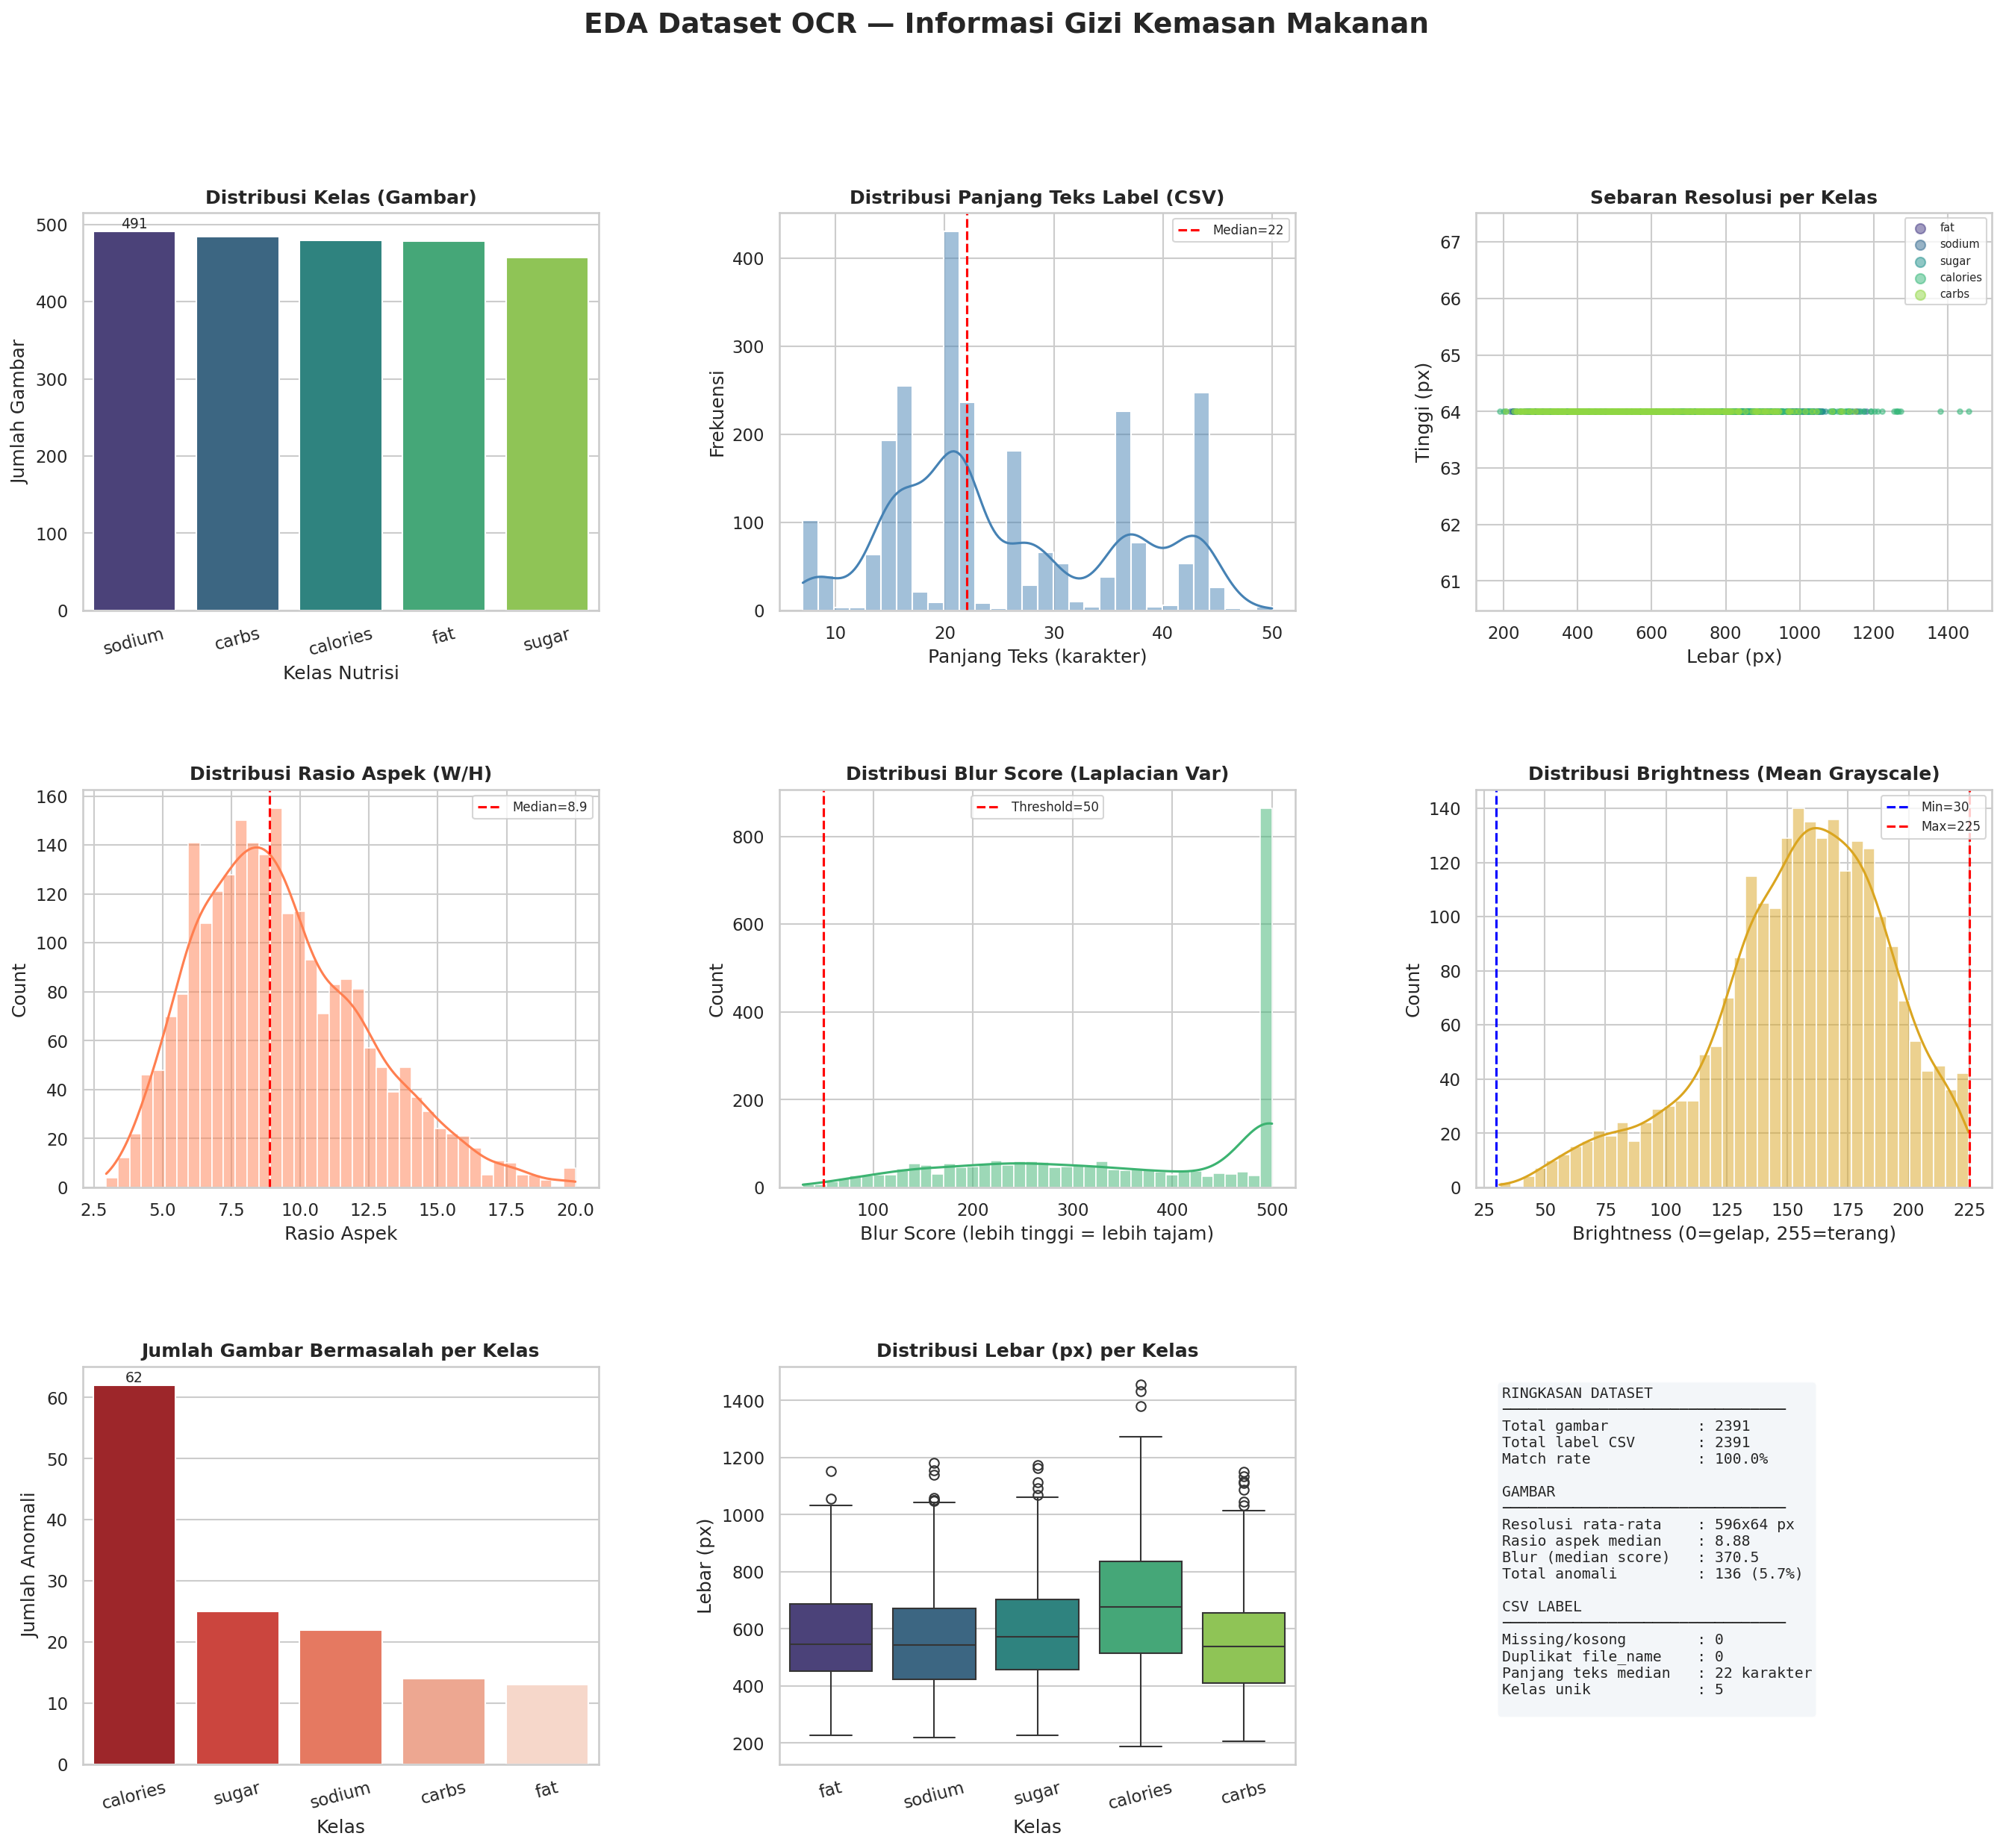


✅ Dashboard disimpan: /content/drive/MyDrive/ocr_crop_v3/cleaned/eda_output/eda_dashboard.png


In [10]:
fig = plt.figure(figsize=(22, 18))
fig.suptitle(
    'EDA Dataset OCR — Informasi Gizi Kemasan Makanan',
    fontsize=18, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

PALETTE = 'viridis'

# ── Plot 1: Class Balance (gambar) ────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
class_count = df_img['class'].value_counts()
bars = sns.barplot(x=class_count.index, y=class_count.values, ax=ax1, palette=PALETTE)
ax1.set_title('Distribusi Kelas (Gambar)', fontweight='bold')
ax1.set_ylabel('Jumlah Gambar')
ax1.set_xlabel('Kelas Nutrisi')
ax1.bar_label(ax1.containers[0], fontsize=9)
ax1.tick_params(axis='x', rotation=15)

# ── Plot 2: Distribusi Panjang Teks ───────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
sns.histplot(df_label['text_len'], bins=30, kde=True, ax=ax2, color='steelblue')
ax2.set_title('Distribusi Panjang Teks Label (CSV)', fontweight='bold')
ax2.set_xlabel('Panjang Teks (karakter)')
ax2.set_ylabel('Frekuensi')
ax2.axvline(df_label['text_len'].median(), color='red', linestyle='--', label=f'Median={df_label["text_len"].median():.0f}')
ax2.legend(fontsize=8)

# ── Plot 3: Resolusi Scatter ───────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
classes_uniq = df_img['class'].unique()
palette_map  = dict(zip(classes_uniq, sns.color_palette(PALETTE, len(classes_uniq))))
for cls in classes_uniq:
    sub = df_img[df_img['class'] == cls]
    ax3.scatter(sub['width'], sub['height'], label=cls, alpha=0.5, s=10, color=palette_map[cls])
ax3.set_title('Sebaran Resolusi per Kelas', fontweight='bold')
ax3.set_xlabel('Lebar (px)')
ax3.set_ylabel('Tinggi (px)')
ax3.legend(fontsize=7, markerscale=2)

# ── Plot 4: Distribusi Rasio Aspek ────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
sns.histplot(df_img['aspect_ratio'].clip(upper=20), bins=40, kde=True, ax=ax4, color='coral')
ax4.set_title('Distribusi Rasio Aspek (W/H)', fontweight='bold')
ax4.set_xlabel('Rasio Aspek')
ax4.axvline(df_img['aspect_ratio'].median(), color='red', linestyle='--',
            label=f'Median={df_img["aspect_ratio"].median():.1f}')
ax4.legend(fontsize=8)

# ── Plot 5: Distribusi Blur Score ─────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
sns.histplot(df_img['blur_score'].clip(upper=500), bins=40, kde=True, ax=ax5, color='mediumseagreen')
ax5.set_title('Distribusi Blur Score (Laplacian Var)', fontweight='bold')
ax5.set_xlabel('Blur Score (lebih tinggi = lebih tajam)')
ax5.axvline(BLUR_THRESHOLD, color='red', linestyle='--', label=f'Threshold={BLUR_THRESHOLD}')
ax5.legend(fontsize=8)

# ── Plot 6: Distribusi Brightness ─────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
sns.histplot(df_img['brightness'], bins=40, kde=True, ax=ax6, color='goldenrod')
ax6.set_title('Distribusi Brightness (Mean Grayscale)', fontweight='bold')
ax6.set_xlabel('Brightness (0=gelap, 255=terang)')
ax6.axvline(BRIGHTNESS_LOW,  color='blue',   linestyle='--', label=f'Min={BRIGHTNESS_LOW}')
ax6.axvline(BRIGHTNESS_HIGH, color='red',    linestyle='--', label=f'Max={BRIGHTNESS_HIGH}')
ax6.legend(fontsize=8)

# ── Plot 7: Anomali per Kelas ─────────────────────────────────
ax7 = fig.add_subplot(gs[2, 0])
anomaly_by_class = df_img.groupby('class')['any_issue'].sum().sort_values(ascending=False)
sns.barplot(x=anomaly_by_class.index, y=anomaly_by_class.values, ax=ax7, palette='Reds_r')
ax7.set_title('Jumlah Gambar Bermasalah per Kelas', fontweight='bold')
ax7.set_ylabel('Jumlah Anomali')
ax7.set_xlabel('Kelas')
ax7.bar_label(ax7.containers[0], fontsize=9)
ax7.tick_params(axis='x', rotation=15)

# ── Plot 8: Boxplot Dimensi per Kelas ────────────────────────
ax8 = fig.add_subplot(gs[2, 1])
sns.boxplot(data=df_img, x='class', y='width', ax=ax8, palette=PALETTE)
ax8.set_title('Distribusi Lebar (px) per Kelas', fontweight='bold')
ax8.set_xlabel('Kelas')
ax8.set_ylabel('Lebar (px)')
ax8.tick_params(axis='x', rotation=15)

# ── Plot 9: Ringkasan Numerik ─────────────────────────────────
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')
summary_text = (
    f"RINGKASAN DATASET\n"
    f"{'─'*32}\n"
    f"Total gambar          : {len(df_img)}\n"
    f"Total label CSV       : {len(df_label)}\n"
    f"Match rate            : {match_rate:.1f}%\n"
    f"\nGAMBAR\n"
    f"{'─'*32}\n"
    f"Resolusi rata-rata    : {df_img['width'].mean():.0f}x{df_img['height'].mean():.0f} px\n"
    f"Rasio aspek median    : {df_img['aspect_ratio'].median():.2f}\n"
    f"Blur (median score)   : {df_img['blur_score'].median():.1f}\n"
    f"Total anomali         : {df_img['any_issue'].sum()} ({df_img['any_issue'].mean()*100:.1f}%)\n"
    f"\nCSV LABEL\n"
    f"{'─'*32}\n"
    f"Missing/kosong        : {missing + empty}\n"
    f"Duplikat file_name    : {dup_rows}\n"
    f"Panjang teks median   : {df_label['text_len'].median():.0f} karakter\n"
    f"Kelas unik            : {df_label['class'].nunique()}\n"
)
ax9.text(0.05, 0.95, summary_text, transform=ax9.transAxes,
         fontsize=9.5, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#f0f4f8', alpha=0.8))

# ── Simpan ────────────────────────────────────────────────────
out_path = os.path.join(OUTPUT_DIR, 'eda_dashboard.png')
plt.savefig(out_path, dpi=200, bbox_inches='tight')
plt.show()
print(f'\n✅ Dashboard disimpan: {out_path}')

## 7. Export Laporan CSV Lengkap

In [11]:
# Gabungkan df_img + df_label jadi satu tabel lengkap
df_full = df_img.merge(df_label[['file_name', 'text', 'text_len']], on='file_name', how='left')

# Simpan laporan lengkap
full_path = os.path.join(OUTPUT_DIR, 'eda_full_report.csv')
df_full.to_csv(full_path, index=False, encoding='utf-8-sig')
print(f'✅ Laporan lengkap disimpan: {full_path}')
print(f'   Shape: {df_full.shape}')
df_full.head()

✅ Laporan lengkap disimpan: /content/drive/MyDrive/ocr_crop_v3/cleaned/eda_output/eda_full_report.csv
   Shape: (2391, 16)


,file_name,class,width,height,aspect_ratio,megapixels,blur_score,brightness,is_blur,is_dark,is_bright,is_odd_ratio,is_too_small,any_issue,text,text_len
0,fat_0540.png,fat,334,64,5.219,0.0214,215.48,58.30,False,False,False,False,False,False,Lemak Total 0 g,15
1,fat_0541.png,fat,506,64,7.906,0.0324,400.11,136.66,False,False,False,False,False,False,Lemak Total / Total Fat 0 g,27
2,fat_0542.png,fat,496,64,7.750,0.0317,553.12,182.15,False,False,False,False,False,False,Lemak Total 0 g,15
3,fat_0543.png,fat,504,64,7.875,0.0323,1074.55,171.90,False,False,False,False,False,False,Lemak Total 16 g,16
4,fat_0544.png,fat,657,64,10.266,0.0420,229.72,144.19,False,False,False,False,False,False,Lemak Total 0 g,15


## 8. Rekomendasi untuk AI Engineer

In [12]:
print('='*60)
print('  REKOMENDASI UNTUK AI ENGINEER (CRNN TRAINING)')
print('='*60)

blur_pct    = df_img['is_blur'].mean() * 100
anomaly_pct = df_img['any_issue'].mean() * 100
class_counts = df_img['class'].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min() if class_counts.min() > 0 else float('inf')

recs = []

# 1. Kualitas gambar
if blur_pct > 10:
    recs.append(f'⚠️  [{blur_pct:.1f}% gambar blur] Pertimbangkan augmentasi sharpening atau filter gambar blur sebelum training.')
else:
    recs.append(f'✅  Kualitas ketajaman gambar baik ({blur_pct:.1f}% blur).')

# 2. Class balance
if imbalance_ratio > 2:
    recs.append(f'⚠️  [Imbalance ratio={imbalance_ratio:.1f}x] Dataset tidak seimbang. Gunakan class_weight atau oversampling (augmentasi) pada kelas minoritas.')
else:
    recs.append(f'✅  Class balance cukup baik (ratio={imbalance_ratio:.1f}x).')

# 3. Resolusi
median_h = df_img['height'].median()
if median_h < 32:
    recs.append(f'⚠️  [Median tinggi={median_h:.0f}px] Terlalu kecil untuk CRNN. Rekomendasikan resize ke tinggi 32–64px.')
else:
    recs.append(f'✅  Tinggi gambar cukup untuk CRNN (median={median_h:.0f}px). Target resize: 32px atau 64px.')

# 4. CSV
if missing + empty > 0:
    recs.append(f'⚠️  [{missing+empty} label kosong] Hapus atau perbaiki sebelum training untuk menghindari error loss.')
else:
    recs.append('✅  Tidak ada label kosong dalam CSV.')

# 5. Match rate
if match_rate < 98:
    recs.append(f'⚠️  [Match rate={match_rate:.1f}%] Ada ketidakcocokan antara gambar dan CSV. Selaraskan sebelum training.')
else:
    recs.append(f'✅  Konsistensi CSV-gambar sangat baik ({match_rate:.1f}%).')

# 6. Preprocessing saran
recs.append('📌 Saran preprocessing CRNN:')
recs.append('   - Resize semua gambar ke tinggi tetap (32px atau 64px), lebar proporsional')
recs.append('   - Normalisasi pixel ke [0,1] atau [-1,1]')
recs.append('   - Gunakan CTC Loss untuk training sequence labeling')
recs.append('   - Split dataset: 80% train / 10% val / 10% test (stratified per kelas)')

print()
for r in recs:
    print(f'  {r}')

# Simpan rekomendasi ke txt
rec_path = os.path.join(OUTPUT_DIR, 'rekomendasi_ai_engineer.txt')
with open(rec_path, 'w', encoding='utf-8') as f:
    f.write('REKOMENDASI UNTUK AI ENGINEER — CRNN TRAINING\n')
    f.write('='*60 + '\n')
    for r in recs:
        f.write(r + '\n')
print(f'\n📄 Rekomendasi disimpan: {rec_path}')

  REKOMENDASI UNTUK AI ENGINEER (CRNN TRAINING)

  ✅  Kualitas ketajaman gambar baik (0.5% blur).
  ✅  Class balance cukup baik (ratio=1.1x).
  ✅  Tinggi gambar cukup untuk CRNN (median=64px). Target resize: 32px atau 64px.
  ✅  Tidak ada label kosong dalam CSV.
  ✅  Konsistensi CSV-gambar sangat baik (100.0%).
  📌 Saran preprocessing CRNN:
     - Resize semua gambar ke tinggi tetap (32px atau 64px), lebar proporsional
     - Normalisasi pixel ke [0,1] atau [-1,1]
     - Gunakan CTC Loss untuk training sequence labeling
     - Split dataset: 80% train / 10% val / 10% test (stratified per kelas)

📄 Rekomendasi disimpan: /content/drive/MyDrive/ocr_crop_v3/cleaned/eda_output/rekomendasi_ai_engineer.txt


---
## Catatan Akhir

File output tersimpan di `D:/ocr_crop_V3/eda_output/`:
| File | Isi |
|---|---|
| `eda_dashboard.png` | Dashboard visualisasi lengkap (untuk laporan) |
| `eda_full_report.csv` | Tabel gabungan semua fitur gambar + label |
| `anomaly_images.csv` | Daftar gambar yang terdeteksi bermasalah |
| `rekomendasi_ai_engineer.txt` | Ringkasan rekomendasi tertulis |